Loaded dataset with 380 rows and 14 columns

Column names found in dataset:
['ID Number', 'Submission Date', 'Application Property', 'Source', 'Age', 'Race/Ethnicity', 'Disability', 'Current Residence', 'HH Size', 'Dependents', 'HH Type', 'HH Income', 'HH Assets', 'FTHB Class?']

Detected columns -> Age: Age, Income: HH Income, Assets: HH Assets

Cleaned dataset: 258 rows remaining after filtering.

Summary Statistics (Income, Assets, Ratios):
           HH Income      HH Assets  Asset_Income_Ratio   Total_Wealth
count     258.000000     258.000000          258.000000     258.000000
mean    61225.928682   50650.926357            1.045857  111876.855039
std     17525.715825   53274.047550            1.735599   51128.268196
min     19044.000000       0.000000            0.000000   35000.000000
25%     49000.000000   20000.000000            0.283890   80000.000000
50%     60150.000000   37500.000000            0.601471  103950.000000
75%     73000.000000   63000.000000            1.000000

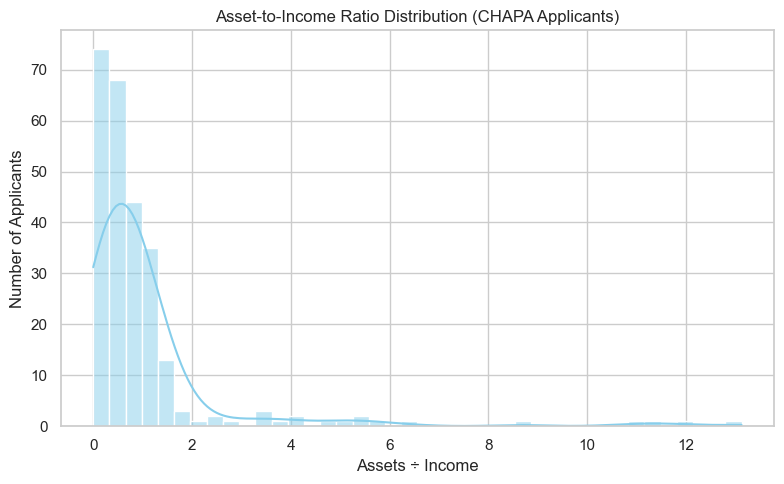

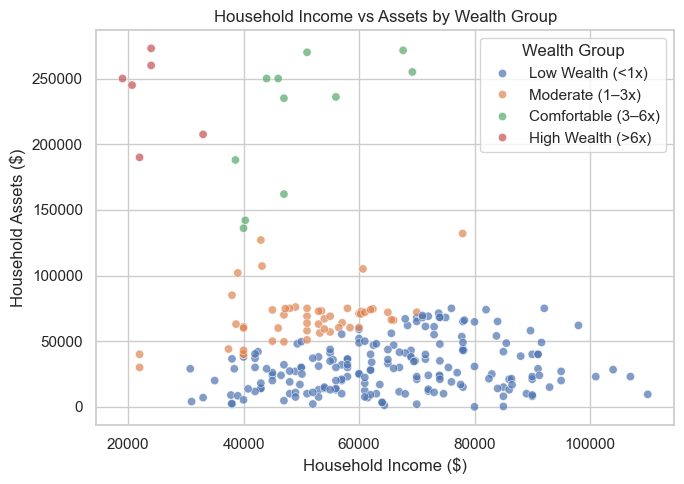

Cleaned data and charts saved to folder: output/
Analysis complete.


In [8]:
# =====================================================
# Project: CHAPA Chapter 40B Affordable Housing Analysis
# Focus: Income, Assets, and Wealth Patterns (2021–2023)
# Author: Aadi Sharma
# =====================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. Load Data
DATA_PATH = "data/CHAPA Chapter 40B Application Data_June 2021 to Sept 2023 - Confidential.xlsx"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Data file not found at {DATA_PATH}")

df = pd.read_excel(DATA_PATH)
print(f"Loaded dataset with {len(df)} rows and {len(df.columns)} columns\n")
print("Column names found in dataset:")
print(list(df.columns))
print()

# 2. Identify Column Names
def find_col(df, possible_names):
    for name in df.columns:
        for key in possible_names:
            if key.lower() in name.lower():
                return name
    return None

age_col = find_col(df, ["age"])
income_col = find_col(df, ["income"])
assets_col = find_col(df, ["asset"])

print(f"Detected columns -> Age: {age_col}, Income: {income_col}, Assets: {assets_col}\n")

if not all([age_col, income_col, assets_col]):
    raise KeyError("Could not detect one or more required columns (Age, Income, Assets).")

# 3. Convert to Numeric
for col in [age_col, income_col, assets_col]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 4. Clean and Filter
df = df[df[age_col] >= 18]
df = df[df[income_col].notna() & df[assets_col].notna()]
df = df[df[income_col] > 0]

print(f"Cleaned dataset: {len(df)} rows remaining after filtering.\n")

# 5. Wealth Metrics
df["Asset_Income_Ratio"] = df[assets_col] / df[income_col]
df["Total_Wealth"] = df[assets_col] + df[income_col]

def wealth_group(row):
    ratio = row["Asset_Income_Ratio"]
    if pd.isna(ratio):
        return 'Unknown'
    elif ratio < 1:
        return 'Low Wealth (<1x)'
    elif ratio < 3:
        return 'Moderate (1–3x)'
    elif ratio < 6:
        return 'Comfortable (3–6x)'
    else:
        return 'High Wealth (>6x)'

df["Wealth_Group"] = df.apply(wealth_group, axis=1)

# 6. Create Output Folder
OUTPUT_DIR = "output"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# 7. Summary
print("Summary Statistics (Income, Assets, Ratios):")
print(df[[income_col, assets_col, "Asset_Income_Ratio", "Total_Wealth"]].describe())
print("\nWealth Group Distribution:")
print(df["Wealth_Group"].value_counts(dropna=False))
print()

# 8. Visualizations
sns.set(style="whitegrid")

# Histogram: Asset-to-Income Ratio
plt.figure(figsize=(8, 5))
sns.histplot(df["Asset_Income_Ratio"], bins=40, kde=True, color="skyblue")
plt.title("Asset-to-Income Ratio Distribution (CHAPA Applicants)")
plt.xlabel("Assets ÷ Income")
plt.ylabel("Number of Applicants")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/Asset_Income_Ratio_Distribution.png")
plt.show()

# Scatter: Income vs Assets
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x=income_col, y=assets_col, hue="Wealth_Group", alpha=0.7)
plt.title("Household Income vs Assets by Wealth Group")
plt.xlabel("Household Income ($)")
plt.ylabel("Household Assets ($)")
plt.legend(title="Wealth Group")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/Income_vs_Assets.png")
plt.show()

# 9. Save Cleaned Data
output_path = f"{OUTPUT_DIR}/chapa_cleaned.csv"
df.to_csv(output_path, index=False)
print(f"Cleaned data and charts saved to folder: {OUTPUT_DIR}/")
print("Analysis complete.")